<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/2%2Bmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

バックテストを実行中...
       2.0    5.0    7.0    10.0   15.0   20.0   30.0   40.0
0     0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
1     0.000 -0.005 -0.004 -0.005 -0.011 -0.009 -0.014 -0.017
2     0.005  0.015  0.005  0.005  0.000  0.005  0.008  0.012
3    -0.006  0.000  0.000  0.000 -0.005  0.004  0.006  0.009
4     0.000  0.006  0.010  0.015  0.026  0.024  0.009  0.009
...     ...    ...    ...    ...    ...    ...    ...    ...
1107 -0.016 -0.019 -0.023 -0.019 -0.011  0.004  0.008  0.016
1108  0.079  0.097  0.097  0.085  0.073  0.060  0.039  0.060
1109  0.016  0.015  0.014  0.009 -0.008 -0.017 -0.027 -0.041
1110  0.010  0.015  0.008  0.000 -0.009 -0.022 -0.028 -0.038
1111 -0.015 -0.034 -0.037 -0.034 -0.040 -0.038 -0.031 -0.035

[1112 rows x 8 columns]
0       0.000
1       0.000
2       0.000
3       0.000
4       0.000
        ...  
1107    4.291
1108    4.158
1109    4.183
1110    4.214
1111    4.282
Length: 1112, dtype: float64
----------------------------------------
最終累積損

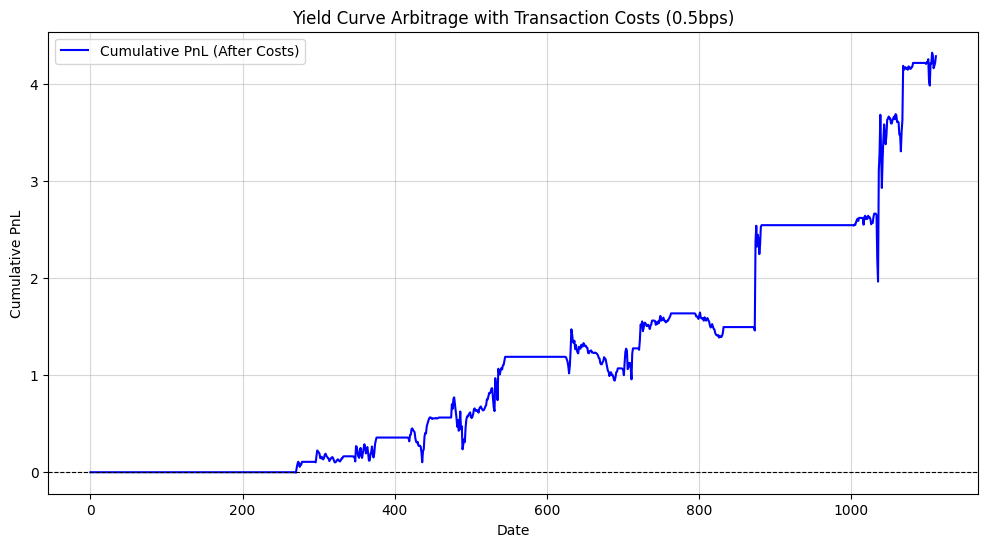

In [2]:
#改造版
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings

# 最適化時の不要な警告を非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. ネルソン・シーゲルモデルの関数定義
# ==========================================
def nelson_siegel(t, beta0, beta1, beta2, tau):
    term1 = beta0
    term2 = beta1 * ((1 - np.exp(-t / tau)) / (t / tau))
    term3 = beta2 * (((1 - np.exp(-t / tau)) / (t / tau)) - np.exp(-t / tau))
    return term1 + term2 + term3

def objective_function(params, t, actual_yields):
    theoretical = nelson_siegel(t, *params)
    return np.sum((actual_yields - theoretical) ** 2)

# ==========================================
# 2. 2年分の時系列データの生成（前回と同じ）
# ==========================================
np.random.seed(42)


maturities = np.array([2.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 40.0])



df_1 = pd.read_csv("債券複利データセット3.csv")
df_1 = df_1.drop(df_1.columns[0], axis=1)
columns_len = len(df_1.columns)
days = len(df_1)
df_1
y_df = df_1

#y_df = y_df.drop('GJGC7',axis=1)
#y_df = y_df.drop('GJGC2',axis=1)
#y_df = y_df.drop('GJGC5',axis=1)
#y_df = y_df.drop('GJGC10',axis=1)
#y_df = y_df.drop('GJGC15',axis=1)
#y_df = y_df.drop('GJGC20',axis=1)
#y_df = y_df.drop('GJGC30',axis=1)
#y_df = y_df.drop('GJGC40',axis=1)

df_yields = y_df
df_yields.columns = [2.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 40.0]

#df_yields = pd.DataFrame(yields_data, index=dates, columns=maturities)

# ==========================================
# 3. バックテストの実行（乖離でエントリー、収束でエグジット）
# ==========================================
entry_threshold_bps = 0.15 # エントリー閾値（5bps以上乖離でエントリー）
exit_threshold_bps  = 0.00 # エグジット閾値（1bps以下まで収束で決済）

# 毎日のポジションを保存するリスト
positions_list = []
# 現在のポジション状態を保持する配列 (0: ノーポジ, 1: ロング, -1: ショート)
current_positions = np.zeros(len(maturities))
init_guess = [4.0, -2.0, 0.0, 2.0]
print("バックテストを実行中...")
for i in range(days):
    #try:
    if i < 10:
      positions_list.append(np.zeros(len(maturities)))
      continue
    else:
      daily_yields_30 = df_yields.iloc[i-10:i].values
    #except:
      #positions_list.append(np.zeros(len(maturities)))
      #continue
    daily_yields = df_yields.iloc[i].values
    # 毎日のイールドカーブ・フィッティング
    #init_guess = [4.0, -2.0, 0.0, 2.0]
    res = minimize(objective_function, init_guess, args=(maturities, daily_yields_30), method='L-BFGS-B')
    fitted_yields = nelson_siegel(maturities, *res.x)
    init_guess =  res.x

    # スプレッド（実測値 - 理論値）
    spread = daily_yields - fitted_yields
    #print(spread)

    # 各年限ごとにエントリー・エグジットの判定
    for j in range(len(maturities)):

        s = spread[j]

        if current_positions[j] == 0:
            # ノーポジションの場合：乖離が大きければエントリー
            if s > entry_threshold_bps:
                current_positions[j] = 1   # 実測利回りが高い（価格が安い） -> ロング
            elif s < -entry_threshold_bps:
                current_positions[j] = -1  # 実測利回りが低い（価格が高い） -> ショート

        elif current_positions[j] == 1:
            # ロングポジション保有中の場合：スプレッドが縮小したらエグジット
            if s <= exit_threshold_bps:
                current_positions[j] = 0   # 利益確定

        elif current_positions[j] == -1:
            # ショートポジション保有中の場合：スプレッドが縮小（0付近に上昇）したらエグジット
            if s >= -exit_threshold_bps:
                current_positions[j] = 0   # 利益確定

    # その日の最終的なポジションを記録
    positions_list.append(current_positions.copy())

positions = pd.DataFrame(positions_list,  columns=maturities)

# ==========================================
# 4. 損益（PnL）の計算と評価（コスト考慮版）
# ==========================================
# 日次の利回り変化（ΔYield）
daily_yield_change = df_yields.diff().fillna(0)
print(daily_yield_change)

# 基本損益 = 前日のポジション * (-年限) * 日次の利回り変化
pnl_matrix = positions.shift(1).fillna(0) * (-1) * daily_yield_change

# --- 取引コストの計算 ---
# ポジションの変化（エントリーまたはエグジット）を特定
position_change = positions.diff().abs().fillna(0)

# コスト = 変化したポジション数 * 0.5bps (0.005%)
# ※ 債券の売買コストを0.005%と仮定
transaction_cost_pct = 0.005
daily_costs = position_change.sum(axis=1) * transaction_cost_pct

# 損益からコストを引く
daily_pnl = pnl_matrix.sum(axis=1) - daily_costs
cumulative_pnl = daily_pnl.cumsum()
print(cumulative_pnl)

# 最終結果の表示
print("-" * 40)
print(f"最終累積損益 (コスト控除後): {cumulative_pnl.iloc[-1]:.4f}")
print(f"総取引回数: {int((position_change.sum().sum()) / 2)} 回")
print(f"総取引コスト: {daily_costs.sum():.4f}")
print("-" * 40)

# ==========================================
# 5. グラフの描画（変更なし）
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(cumulative_pnl, label='Cumulative PnL (After Costs)', color='blue', linewidth=1.5)
plt.title('Yield Curve Arbitrage with Transaction Costs (0.5bps)')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
print(type(daily_yield_change))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
positions

,2.0,5.0,7.0,10.0,15.0,20.0,30.0,40.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1107,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1108,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1109,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1110,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:

pnl_matrix

,2.0,5.0,7.0,10.0,15.0,20.0,30.0,40.0
0,-0.0,-0.0,-0.0,-0.0,-0.000,-0.000,-0.000,-0.000
1,-0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000
2,-0.0,-0.0,-0.0,-0.0,-0.000,-0.000,-0.000,-0.000
3,0.0,-0.0,-0.0,-0.0,0.000,-0.000,-0.000,-0.000
4,-0.0,-0.0,-0.0,-0.0,-0.000,-0.000,-0.000,-0.000
...,...,...,...,...,...,...,...,...
1107,0.0,0.0,0.0,0.0,0.011,-0.004,-0.008,-0.016
1108,-0.0,-0.0,-0.0,-0.0,-0.073,-0.060,-0.000,-0.000
1109,-0.0,-0.0,-0.0,-0.0,0.008,0.017,0.000,0.000
1110,-0.0,-0.0,-0.0,-0.0,0.009,0.022,0.000,0.000


In [ ]:
daily_yield_change

,2.0,5.0,7.0,10.0,15.0,20.0,30.0,40.0
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.000,-0.005,-0.004,-0.005,-0.011,-0.009,-0.014,-0.017
2,0.005,0.015,0.005,0.005,0.000,0.005,0.008,0.012
3,-0.006,0.000,0.000,0.000,-0.005,0.004,0.006,0.009
4,0.000,0.006,0.010,0.015,0.026,0.024,0.009,0.009
...,...,...,...,...,...,...,...,...
1107,-0.016,-0.019,-0.023,-0.019,-0.011,0.004,0.008,0.016
1108,0.079,0.097,0.097,0.085,0.073,0.060,0.039,0.060
1109,0.016,0.015,0.014,0.009,-0.008,-0.017,-0.027,-0.041
1110,0.010,0.015,0.008,0.000,-0.009,-0.022,-0.028,-0.038


In [ ]:
for i in range(len(daily_pnl)):
    print("i",i)
    print(daily_pnl[i])

In [ ]:
positions

,2.0,5.0,7.0,10.0,15.0,20.0,30.0,40.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1097,0.0,1.0,0.0,-1.0,1.0,1.0,0.0,0.0
1098,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
1099,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
1100,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
daily_yields = df_yields.iloc[0:90].values
daily_yields

array([[-1.28e-01, -1.14e-01, -8.00e-02,  3.00e-02,  2.42e-01,  4.14e-01,
         6.49e-01,  6.66e-01],
       [-1.28e-01, -1.19e-01, -8.40e-02,  2.50e-02,  2.31e-01,  4.05e-01,
         6.35e-01,  6.49e-01],
       [-1.23e-01, -1.04e-01, -7.90e-02,  3.00e-02,  2.31e-01,  4.10e-01,
         6.43e-01,  6.61e-01],
       [-1.29e-01, -1.04e-01, -7.90e-02,  3.00e-02,  2.26e-01,  4.14e-01,
         6.49e-01,  6.70e-01],
       [-1.29e-01, -9.80e-02, -6.90e-02,  4.50e-02,  2.52e-01,  4.38e-01,
         6.58e-01,  6.79e-01],
       [-1.25e-01, -1.08e-01, -7.90e-02,  4.00e-02,  2.57e-01,  4.43e-01,
         6.58e-01,  6.74e-01],
       [-1.30e-01, -1.14e-01, -8.90e-02,  3.50e-02,  2.52e-01,  4.47e-01,
         6.63e-01,  6.82e-01],
       [-1.36e-01, -1.19e-01, -8.90e-02,  3.00e-02,  2.41e-01,  4.32e-01,
         6.49e-01,  6.66e-01],
       [-1.36e-01, -1.15e-01, -7.90e-02,  3.50e-02,  2.60e-01,  4.47e-01,
         6.53e-01,  6.74e-01],
       [-1.37e-01, -1.19e-01, -7.90e-02,  3.50e-02,  2.

バックテストを実行中...
       2.0    5.0    7.0    10.0   15.0   20.0   30.0   40.0
0     0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
1     0.000 -0.005 -0.004 -0.005 -0.011 -0.009 -0.014 -0.017
2     0.005  0.015  0.005  0.005  0.000  0.005  0.008  0.012
3    -0.006  0.000  0.000  0.000 -0.005  0.004  0.006  0.009
4     0.000  0.006  0.010  0.015  0.026  0.024  0.009  0.009
...     ...    ...    ...    ...    ...    ...    ...    ...
1107 -0.016 -0.019 -0.023 -0.019 -0.011  0.004  0.008  0.016
1108  0.079  0.097  0.097  0.085  0.073  0.060  0.039  0.060
1109  0.016  0.015  0.014  0.009 -0.008 -0.017 -0.027 -0.041
1110  0.010  0.015  0.008  0.000 -0.009 -0.022 -0.028 -0.038
1111 -0.015 -0.034 -0.037 -0.034 -0.040 -0.038 -0.031 -0.035

[1112 rows x 8 columns]
----------------------------------------
最終累積損益 (コスト控除後): 2.0830
総取引回数: 14 回
総取引コスト: 0.2900
----------------------------------------


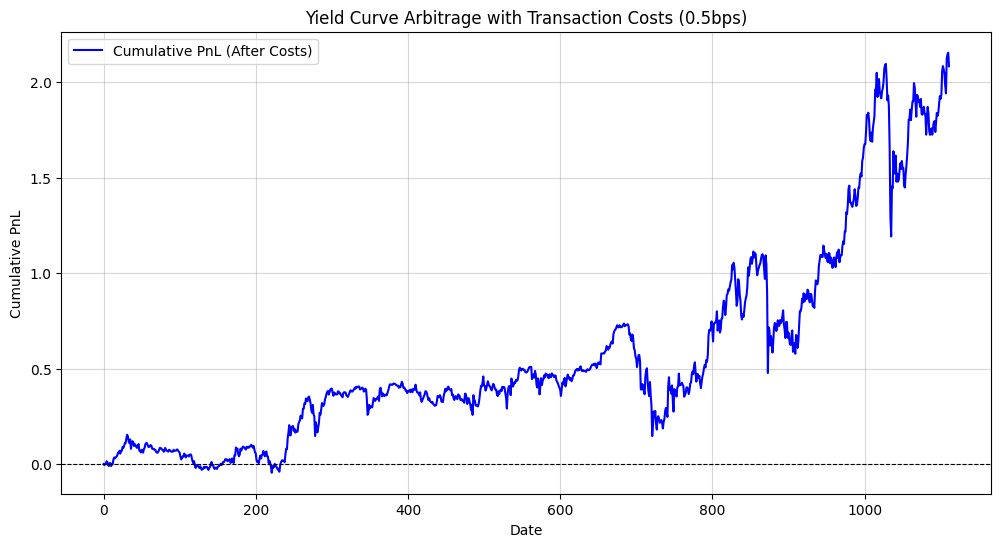

In [1]:
#ペアバージョン
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings

# 最適化時の不要な警告を非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. ネルソン・シーゲルモデルの関数定義
# ==========================================
def nelson_siegel(t, beta0, beta1, beta2, tau):
    term1 = beta0
    term2 = beta1 * ((1 - np.exp(-t / tau)) / (t / tau))
    term3 = beta2 * (((1 - np.exp(-t / tau)) / (t / tau)) - np.exp(-t / tau))
    return term1 + term2 + term3

def objective_function(params, t, actual_yields):
    theoretical = nelson_siegel(t, *params)
    return np.sum((actual_yields - theoretical) ** 2)

# ==========================================
# 2. 2年分の時系列データの生成（前回と同じ）
# ==========================================
np.random.seed(42)


maturities = np.array([2.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 40.0])



df_1 = pd.read_csv("債券複利データセット3.csv")
df_1 = df_1.drop(df_1.columns[0], axis=1)
columns_len = len(df_1.columns)
days = len(df_1)
df_1
y_df = df_1

#y_df = y_df.drop('GJGC7',axis=1)
#y_df = y_df.drop('GJGC2',axis=1)
#y_df = y_df.drop('GJGC5',axis=1)
#y_df = y_df.drop('GJGC10',axis=1)
#y_df = y_df.drop('GJGC15',axis=1)
#y_df = y_df.drop('GJGC20',axis=1)
#y_df = y_df.drop('GJGC30',axis=1)
#y_df = y_df.drop('GJGC40',axis=1)

df_yields = y_df
df_yields.columns = [2.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 40.0]

#df_yields = pd.DataFrame(yields_data, index=dates, columns=maturities)

# ==========================================
# 3. バックテストの実行（乖離でエントリー、収束でエグジット）
# ==========================================
entry_threshold_bps = 0.01 # エントリー閾値（5bps以上乖離でエントリー）
exit_threshold_bps  = 0.00 # エグジット閾値（1bps以下まで収束で決済）

# 毎日のポジションを保存するリスト
positions_list = []
# 現在のポジション状態を保持する配列 (0: ノーポジ, 1: ロング, -1: ショート)
current_positions = np.zeros(len(maturities))
init_guess = [4.0, -2.0, 0.0, 2.0]
print("バックテストを実行中...")
for i in range(days):
    daily_yields = df_yields.iloc[i].values

    # 毎日のイールドカーブ・フィッティング
    #init_guess = [4.0, -2.0, 0.0, 2.0]
    res = minimize(objective_function, init_guess, args=(maturities, daily_yields), method='L-BFGS-B')
    fitted_yields = nelson_siegel(maturities, *res.x)
    init_guess =  res.x

    # スプレッド（実測値 - 理論値）
    spread = daily_yields - fitted_yields

    # 各年限ごとにエントリー・エグジットの判定
    for j in range(len(maturities)):
        if j != 2 and j != 3:
          current_positions[j] = 0
          continue
        s = spread[j]

        if current_positions[j] == 0:
            # ノーポジションの場合：乖離が大きければエントリー
            if s > entry_threshold_bps:
                current_positions[j] = 1   # 実測利回りが高い（価格が安い） -> ロング
            elif s < -entry_threshold_bps:
                current_positions[j] = -1  # 実測利回りが低い（価格が高い） -> ショート

        elif current_positions[j] == 1:
            # ロングポジション保有中の場合：スプレッドが縮小したらエグジット
            if s <= exit_threshold_bps:
                current_positions[j] = 0   # 利益確定

        elif current_positions[j] == -1:
            # ショートポジション保有中の場合：スプレッドが縮小（0付近に上昇）したらエグジット
            if s >= -exit_threshold_bps:
                current_positions[j] = 0   # 利益確定

    # その日の最終的なポジションを記録
    positions_list.append(current_positions.copy())

positions = pd.DataFrame(positions_list,  columns=maturities)

# ==========================================
# 4. 損益（PnL）の計算と評価（コスト考慮版）
# ==========================================
# 日次の利回り変化（ΔYield）
daily_yield_change = df_yields.diff().fillna(0)
print(daily_yield_change)

# 基本損益 = 前日のポジション * (-年限) * 日次の利回り変化
pnl_matrix = positions.shift(1).fillna(0) * (-1) * daily_yield_change

# --- 取引コストの計算 ---
# ポジションの変化（エントリーまたはエグジット）を特定
position_change = positions.diff().abs().fillna(0)

# コスト = 変化したポジション数 * 0.5bps (0.005%)
# ※ 債券の売買コストを0.005%と仮定
transaction_cost_pct = 0.01
daily_costs = position_change.sum(axis=1) * transaction_cost_pct

# 損益からコストを引く
daily_pnl = pnl_matrix.sum(axis=1) - daily_costs
cumulative_pnl = daily_pnl.cumsum()

# 最終結果の表示
print("-" * 40)
print(f"最終累積損益 (コスト控除後): {cumulative_pnl.iloc[-1]:.4f}")
print(f"総取引回数: {int((position_change.sum().sum()) / 2)} 回")
print(f"総取引コスト: {daily_costs.sum():.4f}")
print("-" * 40)

# ==========================================
# 5. グラフの描画（変更なし）
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(cumulative_pnl, label='Cumulative PnL (After Costs)', color='blue', linewidth=1.5)
plt.title('Yield Curve Arbitrage with Transaction Costs (0.5bps)')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
positions

,2.0,5.0,7.0,10.0,15.0,20.0,30.0,40.0
0,0.0,1.0,0.0,-1.0,0.0,0.0,1.0,-1.0
1,0.0,1.0,0.0,-1.0,-1.0,0.0,1.0,-1.0
2,0.0,1.0,0.0,-1.0,-1.0,1.0,1.0,-1.0
3,0.0,1.0,0.0,-1.0,-1.0,1.0,1.0,-1.0
4,0.0,1.0,0.0,-1.0,-1.0,1.0,1.0,-1.0
...,...,...,...,...,...,...,...,...
1107,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0
1108,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0
1109,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0
1110,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0


In [ ]:
daily_costs = position_change["2.0"].sum(axis=1)
daily_costs ['2.0']

KeyError: '2.0'

In [ ]:
positions

,2.0,5.0,7.0,10.0,15.0,20.0,30.0,40.0
0,0.0,1.0,0.0,-1.0,0.0,0.0,1.0,-1.0
1,0.0,1.0,0.0,-1.0,-1.0,0.0,1.0,-1.0
2,0.0,1.0,0.0,-1.0,-1.0,1.0,1.0,-1.0
3,0.0,1.0,0.0,-1.0,-1.0,1.0,1.0,-1.0
4,0.0,1.0,0.0,-1.0,-1.0,1.0,1.0,-1.0
...,...,...,...,...,...,...,...,...
1107,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0
1108,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0
1109,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0
1110,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0


In [ ]:
pnl_matrix = positions.shift(1).fillna(0)* daily_yield_change

pnl_matrix

,2.0,5.0,7.0,10.0,15.0,20.0,30.0,40.0
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.000,-0.005,-0.000,0.005,-0.000,-0.000,-0.014,0.017
2,0.000,0.015,0.000,-0.005,-0.000,0.000,0.008,-0.012
3,-0.000,0.000,0.000,-0.000,0.005,0.004,0.006,-0.009
4,0.000,0.006,0.000,-0.015,-0.026,0.024,0.009,-0.009
...,...,...,...,...,...,...,...,...
1107,0.016,-0.019,0.023,0.019,-0.011,0.004,-0.008,0.000
1108,-0.079,0.097,-0.097,-0.085,0.073,0.060,-0.039,0.000
1109,-0.016,0.015,-0.014,-0.009,-0.008,-0.017,0.027,-0.000
1110,-0.010,0.015,-0.008,-0.000,-0.009,-0.022,0.028,-0.000


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# 1. ネルソン・シーゲル関数の定義
def nelson_siegel(t, beta0, beta1, beta2, tau):
    """各年限tにおける理論利回りを計算する"""
    term1 = beta0
    term2 = beta1 * ((1 - np.exp(-t / tau)) / (t / tau))
    term3 = beta2 * (((1 - np.exp(-t / tau)) / (t / tau)) - np.exp(-t / tau))
    return term1 + term2 + term3

# 2. 誤差関数（フィッティング用）
def objective_function(params, t, actual_yields):
    """実際の利回りと理論利回りの二乗誤差を最小化する"""
    beta0, beta1, beta2, tau = params
    theoretical_yields = nelson_siegel(t, beta0, beta1, beta2, tau)
    # 二乗和誤差 (Sum of Squared Errors)
    return np.sum((actual_yields - theoretical_yields) ** 2)

# ==========================================
# メイン処理：裁定取引戦略のシミュレーション
# ==========================================

# ダミーデータの作成（年限と実際の市場利回り）
# ※実際の市場ではここに国債の利回りデータが入ります
maturities = np.array([1, 2, 3, 5, 7, 10, 20, 30])
actual_yields = np.array([2.0, 2.2, 2.5, 3.1, 3.4, 3.8, 4.2, 4.3])

# 意図的に価格の歪み（ノイズ）を付与して裁定機会を作る
# 5年債を少し割安（利回り高）、10年債を少し割高（利回り低）に設定
actual_yields[3] += 0.15  # 5年債の利回りが理論より高い(価格は安い)
actual_yields[5] -= 0.12  # 10年債の利回りが理論より低い(価格は高い)

# パラメータの初期値 [beta0, beta1, beta2, tau]
initial_guess = [4.0, -2.0, 0.0, 2.0]

# 最適化（カーブ・フィッティング）の実行
result = minimize(objective_function, initial_guess, args=(maturities, actual_yields), method='L-BFGS-B')
best_beta0, best_beta1, best_beta2, best_tau = result.x

# 理論利回りの計算
theoretical_yields = nelson_siegel(maturities, best_beta0, best_beta1, best_beta2, best_tau)

# 裁定取引のシグナル生成
threshold = 0.10  # 裁定を狙う閾値（例: 0.10% = 10bps）
signals = []

for actual, theoretical in zip(actual_yields, theoretical_yields):
    spread = actual - theoretical
    if spread > threshold:
        signals.append("Long (Buy)")   # 利回りが高い = 価格が安すぎる
    elif spread < -threshold:
        signals.append("Short (Sell)") # 利回りが低い = 価格が高すぎる
    else:
        signals.append("Hold")         # 誤差の範囲内

# 結果のデータフレーム化
df_results = pd.DataFrame({
    'Maturity (Years)': maturities,
    'Actual Yield (%)': np.round(actual_yields, 3),
    'Theoretical Yield (%)': np.round(theoretical_yields, 3),
    'Spread (bps)': np.round((actual_yields - theoretical_yields) * 100, 1),
    'Action': signals
})

print("=== 裁定取引シグナル結果 ===")
print(df_results)

# グラフの描画
t_smooth = np.linspace(0.5, 30, 100)
y_smooth = nelson_siegel(t_smooth, best_beta0, best_beta1, best_beta2, best_tau)

plt.figure(figsize=(10, 6))
plt.plot(t_smooth, y_smooth, label='Theoretical Yield Curve', color='blue')
plt.scatter(maturities, actual_yields, color='red', label='Actual Market Yields')
plt.title('Yield Curve Fitting & Arbitrage Strategy')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ltcm_2plus_model(T=1.0, N=252, initial_spread=0.02):
    """
    LTCMの「2+モデル」の概念シミュレーション

    T: シミュレーション期間（年）
    N: ステップ数（252営業日）
    initial_spread: 初期の一時的な歪み（例: 200ベーシスポイント = 0.02）
    """
    dt = T / N
    t = np.linspace(0, T, N)

    # 乱数シードの固定（再現性のため）
    np.random.seed(42)

    # ブラウン運動（ランダムな変動）の生成
    dW_x = np.random.normal(0, np.sqrt(dt), N)
    dW_y = np.random.normal(0, np.sqrt(dt), N)
    dW_z = np.random.normal(0, np.sqrt(dt), N)

    # パラメータ設定 (kappa: 平均回帰の速度, theta: 長期平均, sigma: ボラティリティ)
    # ファクター1: マクロ要因X (金利水準)
    kappa_x, theta_x, sigma_x = 0.5, 0.05, 0.01
    X = np.zeros(N)
    X[0] = 0.05  # 初期金利 5%

    # ファクター2: マクロ要因Y (カーブの傾き等)
    kappa_y, theta_y, sigma_y = 0.3, 0.01, 0.005
    Y = np.zeros(N)
    Y[0] = 0.01

    # ファクター3: スプレッド要因Z (「+」の部分、理論値からの乖離)
    kappa_z, theta_z, sigma_z = 10.0, 0.0, 0.01 # kappa_zが大きい=収束が早い
    Z = np.zeros(N)
    Z[0] = initial_spread # 初期状態で市場に歪み（割安/割高）が発生しているとする

    # オイラー・丸山法によるシミュレーション
    for i in range(1, N):
        X[i] = X[i-1] + kappa_x * (theta_x - X[i-1]) * dt + sigma_x * dW_x[i]
        Y[i] = Y[i-1] + kappa_y * (theta_y - Y[i-1]) * dt + sigma_y * dW_y[i]
        # スプレッドは0 (theta_z) に向かって強く回帰する
        Z[i] = Z[i-1] + kappa_z * (theta_z - Z[i-1]) * dt + sigma_z * dW_z[i]

    # 理論上の利回り (The "2") と 実際の市場利回り (The "2+")
    theoretical_yield = X + Y
    actual_market_yield = X + Y + Z

    return t, theoretical_yield, actual_market_yield, Z

# シミュレーションの実行
t, theoretical_yield, actual_market_yield, spread = simulate_ltcm_2plus_model()

# --- グラフの描画 ---
plt.figure(figsize=(12, 8))

# 上段：利回りの推移（理論値 vs 実際の市場価格）
plt.subplot(2, 1, 1)
plt.plot(t, theoretical_yield, label='Theoretical Yield (X + Y)', color='blue', linestyle='--')
plt.plot(t, actual_market_yield, label='Actual Market Yield (X + Y + Z)', color='red')
plt.title('LTCM "2+" Model Simulation: Yield Convergence')
plt.ylabel('Yield')
plt.legend()
plt.grid(True)

# 下段：スプレッド（歪み）の推移
plt.subplot(2, 1, 2)
plt.plot(t, spread, label='Spread (Z) - The Arbitrage Opportunity', color='green')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.fill_between(t, spread, 0, where=(spread > 0), color='green', alpha=0.3)
plt.title('The "+" Factor: Mean-Reverting Spread')
plt.xlabel('Time (Years)')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()